In [1]:
import pandas as pd

df = pd.read_csv("../data/creditcard.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFraud Distribution:\n", df["Class"].value_counts())
print("\nFraud Ratio:", df["Class"].mean())

Shape: (284807, 31)

Columns:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Fraud Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud Ratio: 0.001727485630620034


In [2]:
print(df["Time"].describe())
print("\nIs Time sorted?", df["Time"].is_monotonic_increasing)

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

Is Time sorted? True


In [3]:
# Chronological split (80% train, 20% test)
split = int(len(df) * 0.8)

train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

print("Train size:", len(train))
print("Test size:", len(test))

print("\nTrain fraud ratio:", train["Class"].mean())
print("Test fraud ratio:", test["Class"].mean())

Train size: 227845
Test size: 56962

Train fraud ratio: 0.001830191577607584
Test fraud ratio: 0.001316667251852112


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

X_train = train.drop(columns=["Class"])
y_train = train["Class"]

X_test = test.drop(columns=["Class"])
y_test = test["Class"]

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC: 0.963313938158103
PR-AUC: 0.7117146481025589

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.97      0.47      0.63        75

    accuracy                           1.00     56962
   macro avg       0.99      0.73      0.82     56962
weighted avg       1.00      1.00      1.00     56962



c:\Users\minnu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

pipe.fit(X_train, y_train)

y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred = pipe.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC: 0.9863223583595548
PR-AUC: 0.7620126617781008

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56887
           1       0.07      0.89      0.13        75

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



In [6]:
import numpy as np
from sklearn.metrics import classification_report

# Try higher threshold
threshold = 0.9
y_custom = (y_prob >= threshold).astype(int)

print("Threshold:", threshold)
print(classification_report(y_test, y_custom))

Threshold: 0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.36      0.83      0.50        75

    accuracy                           1.00     56962
   macro avg       0.68      0.91      0.75     56962
weighted avg       1.00      1.00      1.00     56962



In [7]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold where precision >= 0.80
for p, r, t in zip(precision, recall, np.append(thresholds, 1)):
    if p >= 0.80:
        print("Threshold:", t)
        print("Precision:", p)
        print("Recall:", r)
        break

Threshold: 0.9997092377048454
Precision: 0.8
Recall: 0.7466666666666667


In [8]:
from sklearn.metrics import confusion_matrix

threshold = 0.9997092377048454
y_hat = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_hat)
tn, fp, fn, tp = cm.ravel()

print("Threshold:", threshold)
print("TN (legit correctly allowed):", tn)
print("FP (legit wrongly flagged):", fp)
print("FN (fraud missed):", fn)
print("TP (fraud caught):", tp)

Threshold: 0.9997092377048454
TN (legit correctly allowed): 56873
FP (legit wrongly flagged): 14
FN (fraud missed): 19
TP (fraud caught): 56


In [9]:
fraud_loss = 200
customer_block_cost = 5

total_cost = (fn * fraud_loss) + (fp * customer_block_cost)

print("Estimated Total Cost:", total_cost)
print("Fraud Loss Component:", fn * fraud_loss)
print("Customer Friction Cost:", fp * customer_block_cost)

Estimated Total Cost: 3870
Fraud Loss Component: 3800
Customer Friction Cost: 70


In [10]:
threshold = 0.995
y_hat = (y_prob >= threshold).astype(int)

from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()

fraud_loss = 200
customer_block_cost = 5

total_cost = (fn * fraud_loss) + (fp * customer_block_cost)

print("Threshold:", threshold)
print("TP:", tp, "FN:", fn, "FP:", fp)
print("Total Cost:", total_cost)

Threshold: 0.995
TP: 58 FN: 17 FP: 30
Total Cost: 3550


In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix

fraud_loss = 200
customer_block_cost = 5

thresholds_to_try = np.linspace(0.90, 0.9999, 60)

best = None

for t in thresholds_to_try:
    y_hat = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()
    cost = (fn * fraud_loss) + (fp * customer_block_cost)

    if best is None or cost < best["cost"]:
        best = {"threshold": t, "cost": cost, "tp": tp, "fn": fn, "fp": fp}

best

{'threshold': np.float64(0.9795813559322034),
 'cost': np.int64(3090),
 'tp': np.int64(61),
 'fn': np.int64(14),
 'fp': np.int64(58)}

In [12]:
best_threshold = 0.9795813559322034

y_final = (y_prob >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Final Threshold:", best_threshold)
print("\nClassification Report:\n", classification_report(y_test, y_final))

tn, fp, fn, tp = confusion_matrix(y_test, y_final).ravel()

print("\nConfusion Matrix:")
print("TN:", tn, "FP:", fp)
print("FN:", fn, "TP:", tp)

Final Threshold: 0.9795813559322034

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.51      0.81      0.63        75

    accuracy                           1.00     56962
   macro avg       0.76      0.91      0.81     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
TN: 56829 FP: 58
FN: 14 TP: 61


In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("XGB PR-AUC:", average_precision_score(y_test, y_prob_xgb))

XGB ROC-AUC: 0.9878027200121878
XGB PR-AUC: 0.7898718608374555


In [14]:
from sklearn.metrics import confusion_matrix
import numpy as np

fraud_loss = 200
customer_block_cost = 5

thresholds_to_try = np.linspace(0.90, 0.9999, 80)

best_xgb = None

for t in thresholds_to_try:
    y_hat = (y_prob_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()
    cost = (fn * fraud_loss) + (fp * customer_block_cost)

    if best_xgb is None or cost < best_xgb["cost"]:
        best_xgb = {"threshold": t, "cost": cost, "tp": tp, "fn": fn, "fp": fp}

best_xgb

{'threshold': np.float64(0.9594341772151899),
 'cost': np.int64(3620),
 'tp': np.int64(57),
 'fn': np.int64(18),
 'fp': np.int64(4)}

In [15]:
xgb_tuned = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    gamma=1,
    min_child_weight=5,
    eval_metric="logloss",
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

y_prob_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, average_precision_score

print("Tuned XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_tuned))
print("Tuned XGB PR-AUC:", average_precision_score(y_test, y_prob_xgb_tuned))

Tuned XGB ROC-AUC: 0.9856651490381517
Tuned XGB PR-AUC: 0.8018119572663404


In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np

fraud_loss = 200
customer_block_cost = 5

thresholds_to_try = np.linspace(0.90, 0.9999, 100)

best_xgb_tuned = None

for t in thresholds_to_try:
    y_hat = (y_prob_xgb_tuned >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()
    cost = (fn * fraud_loss) + (fp * customer_block_cost)

    if best_xgb_tuned is None or cost < best_xgb_tuned["cost"]:
        best_xgb_tuned = {
            "threshold": t,
            "cost": cost,
            "tp": tp,
            "fn": fn,
            "fp": fp
        }

best_xgb_tuned

{'threshold': np.float64(0.9736636363636364),
 'cost': np.int64(4210),
 'tp': np.int64(54),
 'fn': np.int64(21),
 'fp': np.int64(2)}

In [17]:
import pandas as pd
import numpy as np

coef = pipe.named_steps["clf"].coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

coef_df["AbsCoef"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values("AbsCoef", ascending=False)

coef_df.head(10)

,Feature,Coefficient,AbsCoef
29,Amount,1.932318,1.932318
14,V14,-1.150408,1.150408
1,V1,1.136151,1.136151
4,V4,1.087985,1.087985
12,V12,-1.015169,1.015169
2,V2,0.943431,0.943431
5,V5,0.902159,0.902159
10,V10,-0.800386,0.800386
20,V20,-0.707187,0.707187
6,V6,-0.681322,0.681322


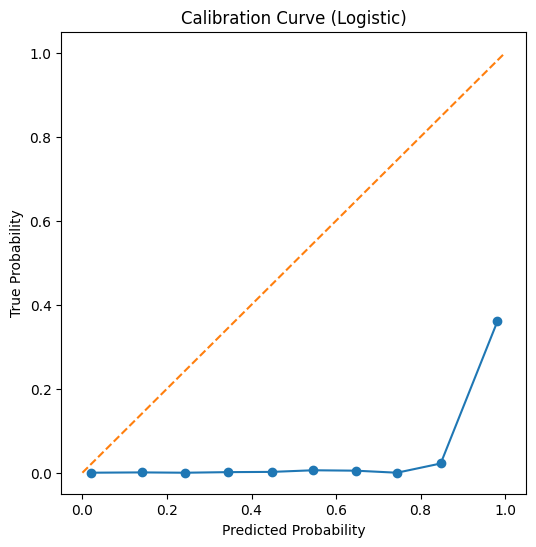

In [18]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve (Logistic)")
plt.show()

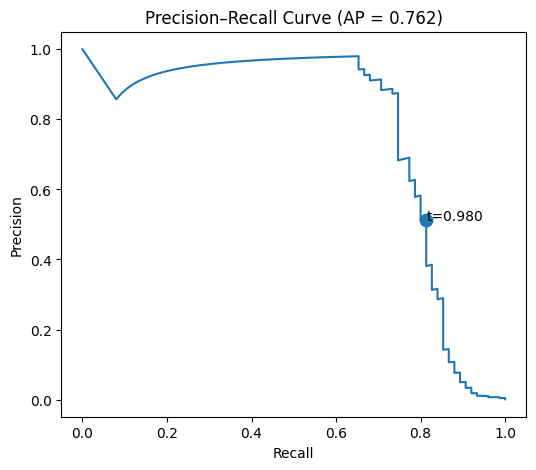

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

best_threshold = 0.9795813559322034

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.title(f"Precision–Recall Curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")

# Mark chosen threshold point
# Find closest threshold index
import numpy as np
idx = np.argmin(np.abs(thresholds - best_threshold))
plt.scatter(recall[idx], precision[idx], s=80)
plt.annotate(f"t={best_threshold:.3f}", (recall[idx], precision[idx]))

plt.show()

In [20]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import precision_recall_curve, average_precision_score

# Fit calibration on TRAIN data only
cal_model = CalibratedClassifierCV(model, method="isotonic", cv=5)
cal_model.fit(X_train, y_train)

# New probabilities
y_prob_cal = cal_model.predict_proba(X_test)[:, 1]

# PR metrics
precision_cal, recall_cal, thresholds_cal = precision_recall_curve(y_test, y_prob_cal)
ap_cal = average_precision_score(y_test, y_prob_cal)

print("Calibrated AP:", ap_cal)

c:\Users\minnu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\minnu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

Calibrated AP: 0.6953237391782455


c:\Users\minnu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Rebuild a clean logistic pipeline
log_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        n_jobs=None,     # lbfgs ignores n_jobs, fine
        class_weight="balanced",
        random_state=42
    ))
])

log_clf.fit(X_train, y_train)

# Probabilities
y_prob = log_clf.predict_proba(X_test)[:, 1]

In [22]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import average_precision_score, precision_recall_curve

cal_model = CalibratedClassifierCV(log_clf, method="isotonic", cv=5)
cal_model.fit(X_train, y_train)

y_prob_cal = cal_model.predict_proba(X_test)[:, 1]

ap_cal = average_precision_score(y_test, y_prob_cal)
print("Calibrated AP (fixed logistic):", ap_cal)

Calibrated AP (fixed logistic): 0.7560240253431634


In [23]:
threshold = 0.995
y_hat = (y_prob_cal >= threshold).astype(int)

from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()

fraud_loss = 200
customer_block_cost = 5

total_cost = (fn * fraud_loss) + (fp * customer_block_cost)

print("Threshold:", threshold)
print("TP:", tp, "FN:", fn, "FP:", fp)
print("Total Cost:", total_cost)

Threshold: 0.995
TP: 0 FN: 75 FP: 0
Total Cost: 15000


In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix

fraud_loss = 200
customer_block_cost = 5

thresholds_to_try = np.linspace(0.90, 0.9999, 60)

best_cal = None

for t in thresholds_to_try:
    y_hat = (y_prob_cal >= t).astype(int)   # <-- only change vs your old cell
    tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()
    cost = (fn * fraud_loss) + (fp * customer_block_cost)

    if best_cal is None or cost < best_cal["cost"]:
        best_cal = {"threshold": t, "cost": cost, "tp": tp, "fn": fn, "fp": fp}

best_cal

{'threshold': np.float64(0.9),
 'cost': np.int64(12205),
 'tp': np.int64(14),
 'fn': np.int64(61),
 'fp': np.int64(1)}

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

t = float(best_cal["threshold"])
y_final_cal = (y_prob_cal >= t).astype(int)

print("Best calibrated threshold:", t)
print("Confusion matrix (TN FP / FN TP):")
print(confusion_matrix(y_test, y_final_cal))
print("\nReport:\n", classification_report(y_test, y_final_cal))
print("\nCost:", best_cal["cost"])

Best calibrated threshold: 0.9
Confusion matrix (TN FP / FN TP):
[[56886     1]
 [   61    14]]

Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.93      0.19      0.31        75

    accuracy                           1.00     56962
   macro avg       0.97      0.59      0.66     56962
weighted avg       1.00      1.00      1.00     56962


Cost: 12205


In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix

# ---- set your tier thresholds ----
t_block = 0.9795813559322034   # your best threshold (high risk)
t_review = 0.90                # start here for medium tier

fraud_loss = 200
block_cost = 5
review_cost = 2   # realistic placeholder (tunable)

# y_prob = model.predict_proba(X_test)[:,1]  # you should already have this
# y_test = ...

# Actions by tier
action = np.where(y_prob >= t_block, "BLOCK",
         np.where(y_prob >= t_review, "REVIEW", "ALLOW"))

# ---- simulate outcomes ----
y_pred_block_only = (y_prob >= t_block).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_block_only).ravel()

# For review tier: count how many legit transactions get reviewed (friction)
review_legit = np.sum((action == "REVIEW") & (y_test == 0))

# Missed fraud = fraud in ALLOW tier (and optionally REVIEW tier if we assume review catches some %)
missed_fraud = np.sum((action == "ALLOW") & (y_test == 1))

total_cost = (missed_fraud * fraud_loss) + (fp * block_cost) + (review_legit * review_cost)

print("Tier policy thresholds:")
print("BLOCK >= ", t_block)
print("REVIEW >= ", t_review, "and < ", t_block)

print("\nCounts:")
print("TP (blocked fraud):", tp)
print("FN (missed fraud in ALLOW):", missed_fraud)
print("FP (blocked legit):", fp)
print("Reviewed legit:", review_legit)

print("\nEstimated Total Cost (3-tier):", total_cost)

Tier policy thresholds:
BLOCK >=  0.9795813559322034
REVIEW >=  0.9 and <  0.9795813559322034

Counts:
TP (blocked fraud): 61
FN (missed fraud in ALLOW): 13
FP (blocked legit): 58
Reviewed legit: 52

Estimated Total Cost (3-tier): 2994


In [27]:
import joblib
joblib.dump(model, "../model/fraud_model.pkl")

['../model/fraud_model.pkl']

In [28]:
import os
import joblib

# Put YOUR final threshold here (the cost-optimized one you decided)
FINAL_THRESHOLD = float(0.9795813559322034)  # <-- replace if you changed it later


artifact = {
    "model": log_clf,  # pipeline: StandardScaler + LogisticRegression
    "block_threshold": FINAL_THRESHOLD,
    "review_threshold": 0.9,
    "feature_names": X_train.columns.tolist()
}

joblib.dump(artifact, "../model/fraud_model.pkl")
print("Saved -> ../model/fraud_model.pkl")
print("Threshold saved:", FINAL_THRESHOLD)
print("Num features:", len(artifact["feature_names"]))

Saved -> ../model/fraud_model.pkl
Threshold saved: 0.9795813559322034
Num features: 30


In [29]:
import numpy as np
from sklearn.metrics import confusion_matrix

# ---- thresholds ----
t_block = 0.9795813559322034   # high risk → block
t_review = 0.90                # medium risk → review

# ---- business costs (tune these) ----
fraud_loss = 200               # cost when fraud is allowed
block_cost = 5                 # friction cost when legit is blocked
review_cost = 2                # cost per reviewed transaction (analyst + friction)

review_catch_rate = 0.70       # % of fraud caught in review (assumption)

# y_prob = model.predict_proba(X_test)[:, 1]
# y_test = ...

# ---- tier actions ----
action = np.where(
    y_prob >= t_block, "BLOCK",
    np.where(y_prob >= t_review, "REVIEW", "ALLOW")
)

# ---- BLOCK metrics (binary at t_block) ----
y_pred_block = (y_prob >= t_block).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_block).ravel()

# ---- counts by tier ----
review_legit = np.sum((action == "REVIEW") & (y_test == 0))
review_fraud = np.sum((action == "REVIEW") & (y_test == 1))

allow_fraud = np.sum((action == "ALLOW") & (y_test == 1))

# Fraud that goes to review: some caught, some missed
caught_in_review = int(round(review_catch_rate * review_fraud))
missed_in_review = review_fraud - caught_in_review

# Total missed fraud = fraud allowed + fraud not caught in review
missed_fraud_total = allow_fraud + missed_in_review

# ---- total cost ----
total_cost = (
    missed_fraud_total * fraud_loss +
    fp * block_cost +
    (review_legit + review_fraud) * review_cost
)

print("Tier policy thresholds:")
print("BLOCK >= ", t_block)
print("REVIEW >= ", t_review, "and < ", t_block)

print("\nCounts:")
print("TP (blocked fraud):", tp)
print("FP (blocked legit):", fp)
print("Review legit:", review_legit)
print("Review fraud:", review_fraud)
print("Fraud caught in review (est):", caught_in_review)
print("Fraud missed total:", missed_fraud_total)

print("\nEstimated Total Cost (3-tier):", total_cost)

Tier policy thresholds:
BLOCK >=  0.9795813559322034
REVIEW >=  0.9 and <  0.9795813559322034

Counts:
TP (blocked fraud): 61
FP (blocked legit): 58
Review legit: 52
Review fraud: 1
Fraud caught in review (est): 1
Fraud missed total: 13

Estimated Total Cost (3-tier): 2996


In [30]:
import os, joblib

BLOCK_THRESHOLD = 0.9795813559322034
REVIEW_THRESHOLD = 0.90


artifact = {
    "model": log_clf,
    "block_threshold": BLOCK_THRESHOLD,
    "review_threshold": REVIEW_THRESHOLD,
    "feature_names": X_train.columns.tolist()
}

joblib.dump(artifact, "../model/fraud_model.pkl")

print("Saved -> ../model/fraud_model.pkl")
print("Block threshold:", BLOCK_THRESHOLD)
print("Review threshold:", REVIEW_THRESHOLD)
print("Features:", len(artifact["feature_names"]))

Saved -> ../model/fraud_model.pkl
Block threshold: 0.9795813559322034
Review threshold: 0.9
Features: 30
